In [3]:
import numpy as np
import matplotlib.pyplot as plt
import nestle
import corner

### Exercise - Egg Carton

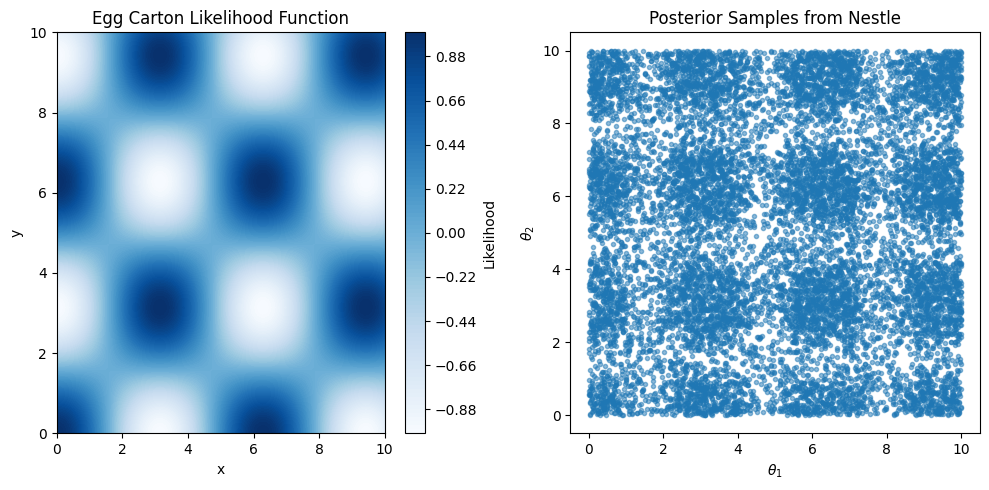

In [13]:
# Define the "egg carton" likelihood function
def egg_carton(theta1, theta2):
    return np.cos(theta1) * np.cos(theta2)

# Define the log-likelihood function for Nestle
def loglike(theta):
    theta1, theta2 = theta
    return (np.cos(theta1) * np.cos(theta2))**2

# Define the prior transformation: maps unit cube [0,1] to parameter range [0,10]
def prior_transform(u):
    theta1 = 10 * u[0]  # Rescale theta1 from [0,1] to [0,10]
    theta2 = 10 * u[1]  # Rescale theta2 from [0,1] to [0,10]
    return np.array([theta1, theta2])

# Run nested sampling using Nestle
result = nestle.sample(loglike, prior_transform, ndim = 2, method = 'multi', npoints = 5000)

# Extract posterior samples
samples = result.samples  # Posterior samples

# Plotting the raster scan of the egg carton likelihood function
x = np.linspace(0, 10, 100)
y = np.linspace(0, 10, 100)

X, Y = np.meshgrid(x, y)
Z = egg_carton(X, Y)

fig, ax = plt.subplots(1, 2, figsize = (10, 5))

ax[0].contourf(X, Y, Z, 100, cmap='Blues')
ax[0].set_xlabel('x')
ax[0].set_ylabel('y')
ax[0].set_title('Egg Carton Likelihood Function')
# Colorbar
cbar = plt.colorbar(ax[0].contourf(X, Y, Z, 100, cmap = 'Blues'), ax = ax[0])
cbar.set_label('Likelihood')        # Higher likelihood is darker (i.e. positive values), lower likelihood is lighter (i.e. negative values)


ax[1].plot(samples[:, 0], samples[:, 1], '.', alpha = 0.5)
ax[1].set_xlabel(r'$\theta_1$')
ax[1].set_ylabel(r'$\theta_2$')
ax[1].set_title('Posterior Samples from Nestle')

plt.tight_layout()
plt.show()

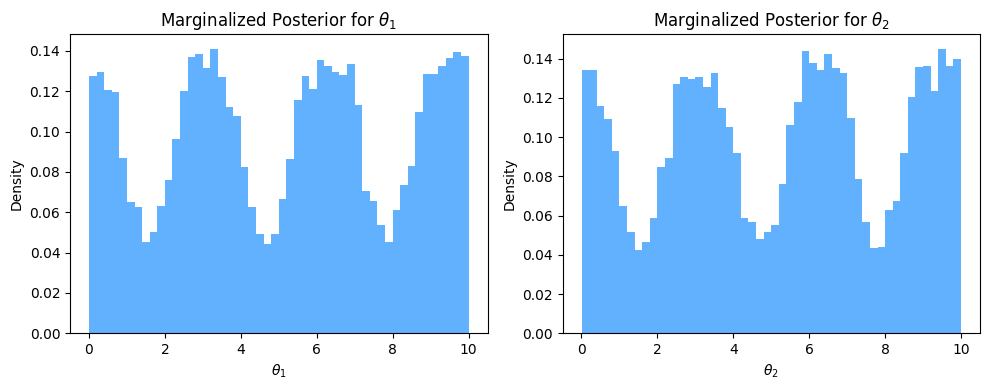

In [14]:
fig, ax = plt.subplots(1, 2, figsize=(10, 4))

ax[0].hist(samples[:, 0], bins=50, color='dodgerblue', alpha=0.7, density=True)
ax[0].set_xlabel(r'$\theta_1$')
ax[0].set_ylabel('Density')
ax[0].set_title('Marginalized Posterior for $\\theta_1$')

ax[1].hist(samples[:, 1], bins=50, color='dodgerblue', alpha=0.7, density=True)
ax[1].set_xlabel(r'$\theta_2$')
ax[1].set_ylabel('Density')
ax[1].set_title('Marginalized Posterior for $\\theta_2$')

plt.tight_layout()
plt.show()

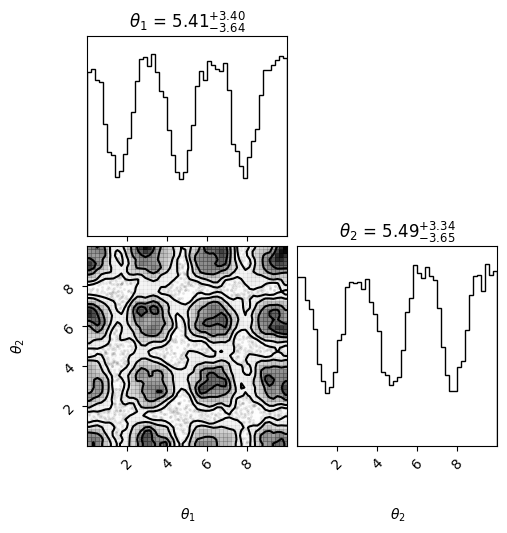

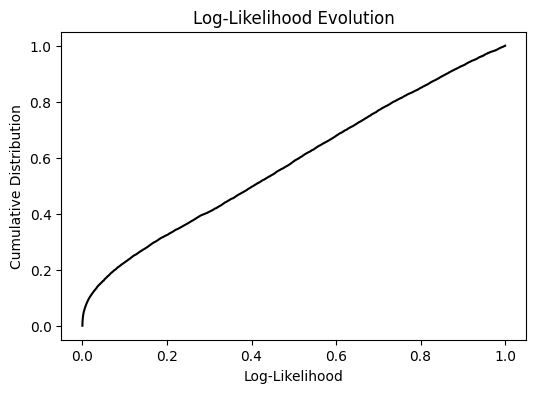

In [19]:
fig = corner.corner(samples, labels = [r"$\theta_1$", r"$\theta_2$"], bins = 50, color = 'black', smooth = True, show_titles = True)
plt.show()

log_likes = result.logl  # Log-likelihood values

plt.figure(figsize=(6, 4))
plt.plot(np.sort(log_likes), np.linspace(0, 1, len(log_likes)), color='black')
plt.xlabel("Log-Likelihood")
plt.ylabel("Cumulative Distribution")
plt.title("Log-Likelihood Evolution")
plt.show()


### Exercise - Gaussian Shell/Cylinder

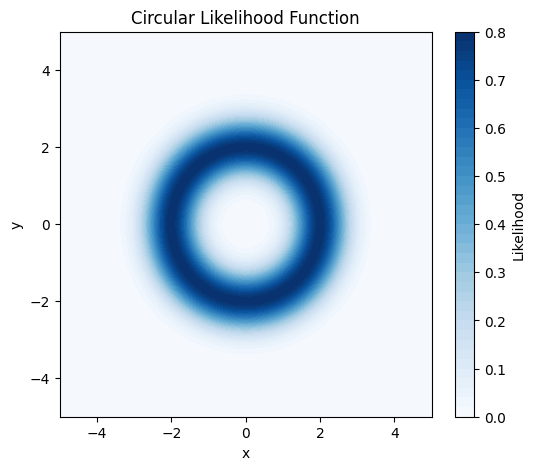

In [22]:
def Gauss_2D_shell(theta, c, r, sigma):
    norm_diff = np.linalg.norm(np.array(theta) - np.array(c))
    shell = (1 / np.sqrt(2 * np.pi * sigma**2)) * np.exp(-((norm_diff - r)**2) / (2 * sigma**2))
    return shell

# Define a grid of points
x = np.linspace(-5, 5, 100)
y = np.linspace(-5, 5, 100)
X, Y = np.meshgrid(x, y)

# Compute likelihood values over the grid
Z = np.array([[Gauss_2D_shell([X[i, j], Y[i, j]], [0, 0], 2.0, 0.5) 
               for j in range(len(y))] for i in range(len(x))])

# Plot the heatmap
plt.figure(figsize = (6, 5))
plt.contourf(X, Y, Z, levels = 50, cmap = "Blues")
plt.colorbar(label = "Likelihood")
plt.title("Circular Likelihood Function")
plt.xlabel("x")
plt.ylabel("y")
plt.show()

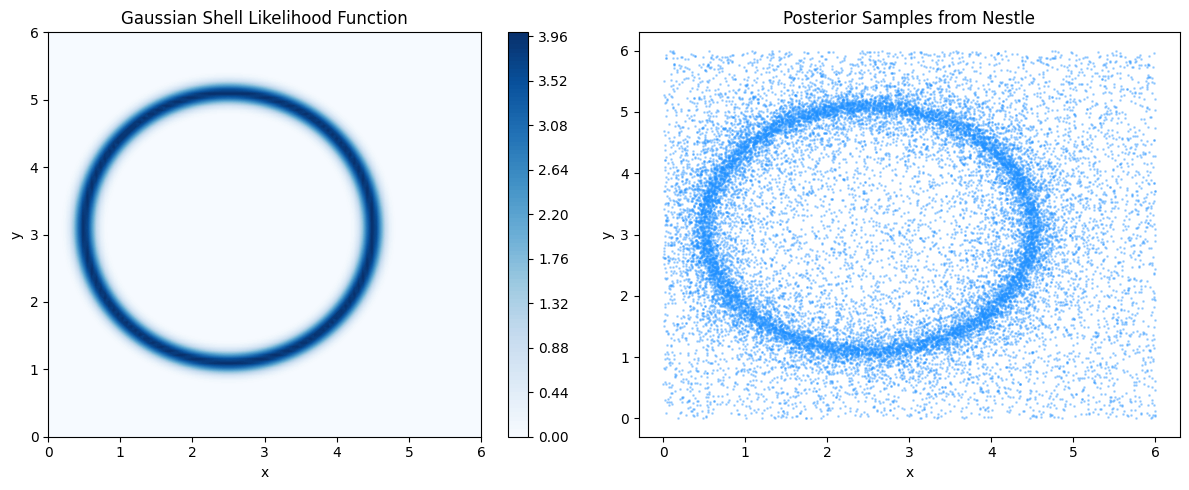

In [33]:
def loglike(theta):
    c = [2.5, 3.1]  # Shell center
    r = 2.0  # Shell radius
    sigma = 0.1  # Gaussian width
    return np.log(Gauss_2D_shell(theta, c, r, sigma) + 1e-8)

def prior_transform(u):
    theta1 = 6 * u[0]  
    theta2 = 6 * u[1]  
    return np.array([theta1, theta2])

# Run nested sampling using Nestle
result = nestle.sample(loglike, prior_transform, ndim = 2, method = 'multi', npoints = 5000)

# Extract posterior samples
samples = result.samples  # Posterior samples

# Define grid for visualization
x = np.linspace(0, 6, 100)
y = np.linspace(0, 6, 100)
X, Y = np.meshgrid(x, y)

# Compute likelihood values over the grid
Z = np.array([[np.exp(loglike([X[i, j], Y[i, j]])) for j in range(len(y))] for i in range(len(x))])

# Plot
fig, ax = plt.subplots(1, 2, figsize=(12, 5))

# Likelihood function plot
c = ax[0].contourf(X, Y, Z, levels = 100, cmap = 'Blues')
ax[0].set_xlabel(r'x')
ax[0].set_ylabel(r'y')
ax[0].set_title('Gaussian Shell Likelihood Function')
fig.colorbar(c, ax = ax[0])

# Posterior samples
ax[1].scatter(samples[:, 0], samples[:, 1], s = 1, alpha = 0.3, color='dodgerblue')
ax[1].set_xlabel(r'x')
ax[1].set_ylabel(r'y')
ax[1].set_title('Posterior Samples from Nestle')

plt.tight_layout()
plt.show()

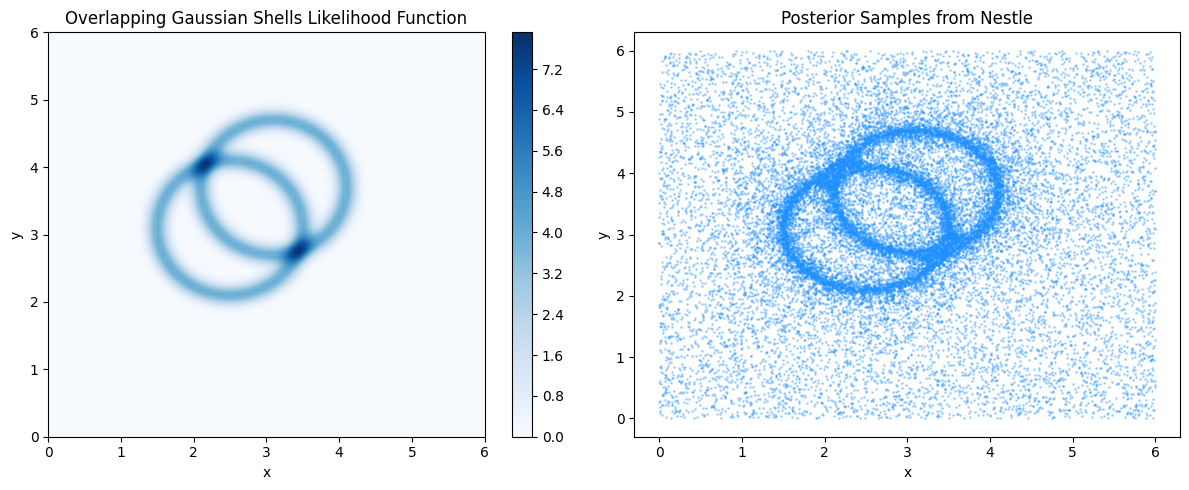

In [39]:
# Making two overlapping Gaussian shells
r, sigma = 1, 0.1
c1 = [2.5, 3.1]
c2 = [3.1, 3.7]

# Sampling
def loglike(theta):
    return np.log(Gauss_2D_shell(theta, c1, r, sigma) + Gauss_2D_shell(theta, c2, r, sigma) + 1e-8)

x = np.linspace(0, 6, 100)
y = np.linspace(0, 6, 100)

X, Y = np.meshgrid(x, y)
Z1 = np.array([[Gauss_2D_shell([X[i, j], Y[i, j]], c1, r, sigma) for j in range(len(y))] for i in range(len(x))])
Z2 = np.array([[Gauss_2D_shell([X[i, j], Y[i, j]], c2, r, sigma) for j in range(len(y))] for i in range(len(x))])

result = nestle.sample(loglike, prior_transform, ndim = 2, method = 'multi', npoints = 5000)
samples = result.samples

fig, ax = plt.subplots(1, 2, figsize=(12, 5))

# Likelihood function plot
c = ax[0].contourf(X, Y, Z1 + Z2, levels = 100, cmap = 'Blues')
ax[0].set_xlabel(r'x')
ax[0].set_ylabel(r'y')
ax[0].set_title('Overlapping Gaussian Shells Likelihood Function')
fig.colorbar(c, ax = ax[0])

# Posterior samples
ax[1].scatter(samples[:, 0], samples[:, 1], s = 1, alpha = 0.3, color = 'dodgerblue')
ax[1].set_xlabel(r'x')
ax[1].set_ylabel(r'y')
ax[1].set_title('Posterior Samples from Nestle')

plt.tight_layout()
plt.show() 

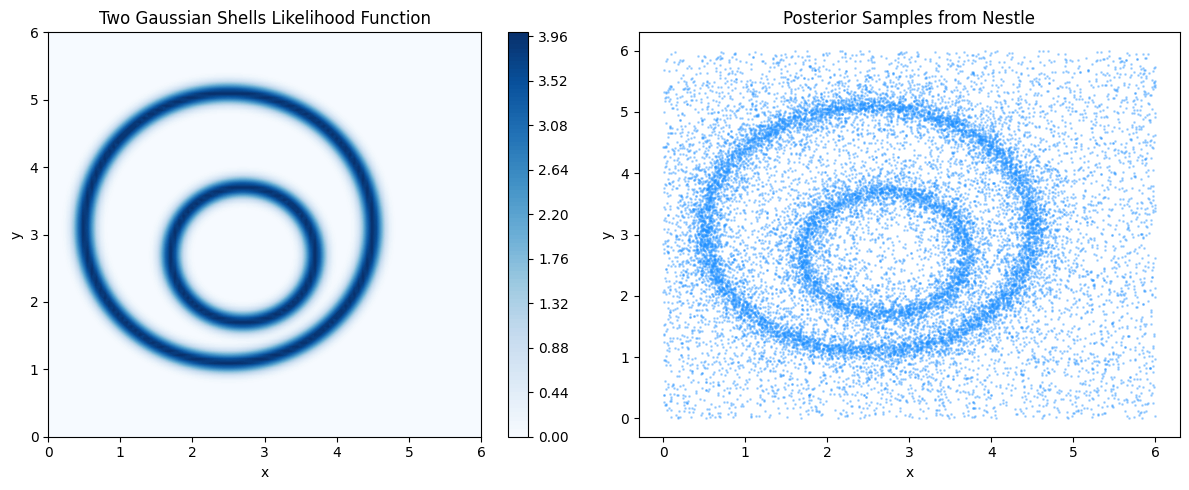

In [40]:
# Two different Gaussian shells
r1, r2 = 2, 1
sigma = 0.1
c1 = [2.5, 3.1]
c2 = [2.7, 2.7]

def loglike(theta):
    return np.log(Gauss_2D_shell(theta, c1, r1, sigma) + Gauss_2D_shell(theta, c2, r2, sigma) + 1e-8)

result = nestle.sample(loglike, prior_transform, ndim = 2, method = 'multi', npoints = 5000)
samples = result.samples

x = np.linspace(0, 6, 100)
y = np.linspace(0, 6, 100)

X, Y = np.meshgrid(x, y)
Z1 = np.array([[Gauss_2D_shell([X[i, j], Y[i, j]], c1, r1, sigma) for j in range(len(y))] for i in range(len(x))])
Z2 = np.array([[Gauss_2D_shell([X[i, j], Y[i, j]], c2, r2, sigma) for j in range(len(y))] for i in range(len(x))])

fig, ax = plt.subplots(1, 2, figsize = (12, 5))

# Likelihood function plot
c = ax[0].contourf(X, Y, Z1 + Z2, levels = 100, cmap = 'Blues')
ax[0].set_xlabel(r'x')
ax[0].set_ylabel(r'y')
ax[0].set_title('Two Gaussian Shells Likelihood Function')
fig.colorbar(c, ax = ax[0])

# Posterior samples
ax[1].scatter(samples[:, 0], samples[:, 1], s = 1, alpha = 0.3, color = 'dodgerblue')
ax[1].set_xlabel(r'x')
ax[1].set_ylabel(r'y')
ax[1].set_title('Posterior Samples from Nestle')

plt.tight_layout()
plt.show()

In [1]:
import math
import time
from collections import OrderedDict

from numpy.random import RandomState
rstate = RandomState(0)

In [5]:
r = 2.
w = 0.1

const = math.log(1. / math.sqrt(2. * math.pi * w**2))

def logcirc(theta, c):
    d = np.sqrt(np.sum((theta - c)**2, axis=-1))  # |theta - c|
    return const - (d - r)**2 / (2. * w**2)

def loglike(theta, c1, c2):
    return np.logaddexp(logcirc(theta, c1), logcirc(theta, c2))

def prior_transform(x):
    """Defines a flat prior between -6 and 6 in all dimensions."""
    return 12. * x - 6.

In [6]:
npoints = 1000

def run(ndim):
    """Convenience function for running in any dimension"""

    c1 = np.zeros(ndim)
    c1[0] = -3.5
    c2 = np.zeros(ndim)
    c2[0] = 3.5
    f = lambda theta: loglike(theta, c1, c2)

    return nestle.sample(f, prior_transform, ndim, method='multi',
                         npoints=npoints, rstate=rstate)

# Run over dimensions and save time for each run.
results = OrderedDict()
for ndim in [2, 5, 10, 20]:
    t0 = time.time()
    results[ndim] = run(ndim)
    results[ndim].time = time.time() - t0

analytic_logz = {2: -1.75,
                 5: -5.67,
                 10: -14.59,
                 20: -36.09}

print("D  analytic    logz  logzerr   nlike  eff(%)   time")
for ndim, res in results.items():
    eff = 100. * res.niter/(res.ncall - npoints)
    print("{:2d}   {:6.2f}  {:6.2f}     {:4.2f}  {:6d}   {:5.2f}  {:6.2f}"
          .format(ndim, analytic_logz[ndim], res.logz, res.logzerr,
                  res.ncall, eff, res.time))

D  analytic    logz  logzerr   nlike  eff(%)   time
 2    -1.75   -1.75     0.05   11585   38.30    0.56
 5    -5.67   -5.68     0.08   25495   32.57    1.52
10   -14.59  -14.61     0.12   50514   34.15    2.95
20   -36.09  -36.18     0.19  182756   21.17   11.39
